In [6]:
# 호환되는 버전 조합으로 강제 설치
!pip install pandas==2.0.3 numpy==1.24.3 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 10.6 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.24.3.tar.gz (10.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "/opt/anaconda3/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/opt/anaconda3/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "/opt/anaconda3/lib/pyt

In [7]:
# ========================================
# 🚀 즉시 해결: Python 3.12 호환 패키지 자동 설치
# ========================================
# pkgutil.ImpImporter 오류 해결

import sys
import subprocess
import importlib.util

def check_python_version():
    """Python 버전 확인"""
    version = sys.version_info
    print(f"🐍 Python 버전: {version.major}.{version.minor}.{version.micro}")
    
    if version.major == 3 and version.minor >= 12:
        print("⚠️ Python 3.12+ 감지: 특별한 처리 필요")
        return True
    return False

def install_compatible_packages():
    """Python 3.12 호환 패키지 설치"""
    
    print("🔧 Python 3.12 호환 패키지 설치 중...")
    
    # Python 3.12와 호환되는 패키지 버전들
    compatible_packages = [
        "pandas==2.1.4",      # Python 3.12 호환
        "numpy==1.26.4",      # Python 3.12 호환  
        "scipy==1.11.4",      # 안정적인 버전
        "scikit-learn==1.3.2", # 최신 안정 버전
        "matplotlib==3.8.2",   # 호환 버전
        "seaborn==0.13.0"      # 최신 버전
    ]
    
    for package in compatible_packages:
        try:
            print(f"📦 {package} 설치 중...")
            
            # --only-binary=all 플래그로 빌드 오류 방지
            result = subprocess.run([
                sys.executable, "-m", "pip", "install", package, 
                "--only-binary=all", "--force-reinstall", "--no-deps"
            ], capture_output=True, text=True, timeout=300)
            
            if result.returncode == 0:
                print(f"   ✅ {package} 설치 완료")
            else:
                print(f"   ⚠️ {package} 설치 실패, conda 시도...")
                
                # conda로 재시도
                conda_result = subprocess.run([
                    "conda", "install", package.replace("==", "="), 
                    "-c", "conda-forge", "-y"
                ], capture_output=True, text=True, timeout=300)
                
                if conda_result.returncode == 0:
                    print(f"   ✅ {package} conda 설치 완료")
                else:
                    print(f"   ❌ {package} 설치 실패")
                    
        except subprocess.TimeoutExpired:
            print(f"   ⏱️ {package} 설치 타임아웃")
        except Exception as e:
            print(f"   ❌ {package} 오류: {e}")
    
    # 의존성 설치
    print("\n🔗 의존성 해결...")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"], 
                      capture_output=True, timeout=60)
        print("   ✅ pip 업그레이드 완료")
    except:
        print("   ⚠️ pip 업그레이드 실패")

def verify_installation():
    """설치 확인"""
    print("\n🔍 설치 확인 중...")
    
    test_packages = {
        'numpy': 'np',
        'pandas': 'pd', 
        'matplotlib.pyplot': 'plt',
        'sklearn': 'sklearn'
    }
    
    success_count = 0
    
    for package, alias in test_packages.items():
        try:
            spec = importlib.util.find_spec(package)
            if spec is not None:
                module = importlib.import_module(package)
                version = getattr(module, '__version__', 'unknown')
                print(f"   ✅ {package}: {version}")
                success_count += 1
            else:
                print(f"   ❌ {package}: 찾을 수 없음")
        except Exception as e:
            print(f"   ❌ {package}: {str(e)[:50]}")
    
    print(f"\n📊 성공률: {success_count}/{len(test_packages)} ({success_count/len(test_packages)*100:.0f}%)")
    
    return success_count >= 3  # 최소 3개 이상 성공

def main():
    """메인 실행 함수"""
    print("🚀 Python 3.12 호환성 문제 자동 해결 시작")
    print("="*60)
    
    # 1. Python 버전 확인
    is_python312 = check_python_version()
    
    # 2. 호환 패키지 설치
    install_compatible_packages()
    
    # 3. 설치 확인
    if verify_installation():
        print("\n🎉 성공! 호환 패키지 설치 완료")
        print("🔄 이제 Kernel → Restart Kernel 하세요!")
        print("\n💡 재시작 후 다음 코드로 확인:")
        print("import pandas as pd")
        print("import numpy as np")
        print("print(f'Pandas: {pd.__version__}')")
        print("print(f'NumPy: {np.__version__}')")
        
        return True
    else:
        print("\n❌ 일부 패키지 설치 실패")
        print("💡 수동 해결 방법:")
        print("1. conda install pandas numpy scikit-learn -c conda-forge")
        print("2. 또는 새 가상환경 생성")
        
        return False

# 실행
if __name__ == "__main__":
    try:
        success = main()
        
        if success:
            print("\n" + "="*60)
            print("✅ 해결 완료! 다음 단계:")
            print("1. Kernel → Restart Kernel")
            print("2. 원래 LightGBM 코드 재실행")
            print("3. 이제 TypeError 없이 동작할 것입니다!")
            
    except KeyboardInterrupt:
        print("\n🛑 사용자가 중단했습니다")
    except Exception as e:
        print(f"\n❌ 예상치 못한 오류: {e}")
        print("💡 수동 해결을 권장합니다")

# 지금 실행!
main()

🚀 Python 3.12 호환성 문제 자동 해결 시작
🐍 Python 버전: 3.10.8
🔧 Python 3.12 호환 패키지 설치 중...
📦 pandas==2.1.4 설치 중...
   ✅ pandas==2.1.4 설치 완료
📦 numpy==1.26.4 설치 중...
   ✅ numpy==1.26.4 설치 완료
📦 scipy==1.11.4 설치 중...
   ✅ scipy==1.11.4 설치 완료
📦 scikit-learn==1.3.2 설치 중...
   ✅ scikit-learn==1.3.2 설치 완료
📦 matplotlib==3.8.2 설치 중...
   ✅ matplotlib==3.8.2 설치 완료
📦 seaborn==0.13.0 설치 중...
   ✅ seaborn==0.13.0 설치 완료

🔗 의존성 해결...
   ✅ pip 업그레이드 완료

🔍 설치 확인 중...
   ✅ numpy: 1.24.3
   ✅ pandas: 2.3.1
   ✅ matplotlib.pyplot: unknown
   ✅ sklearn: 1.7.1

📊 성공률: 4/4 (100%)

🎉 성공! 호환 패키지 설치 완료
🔄 이제 Kernel → Restart Kernel 하세요!

💡 재시작 후 다음 코드로 확인:
import pandas as pd
import numpy as np
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

✅ 해결 완료! 다음 단계:
1. Kernel → Restart Kernel
2. 원래 LightGBM 코드 재실행
3. 이제 TypeError 없이 동작할 것입니다!
🚀 Python 3.12 호환성 문제 자동 해결 시작
🐍 Python 버전: 3.10.8
🔧 Python 3.12 호환 패키지 설치 중...
📦 pandas==2.1.4 설치 중...
   ✅ pandas==2.1.4 설치 완료
📦 numpy==1.26.4 설치 중...
   ✅ numpy==1.26.4 설

True

In [2]:
# ========================================
# 💡 LightGBM 금융상품 추천 모델
# ========================================
# Microsoft에서 개발한 빠른 그래디언트 부스팅

# LightGBM 설치 확인
try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    print("✅ LightGBM 사용 가능")
except ImportError:
    print("❌ LightGBM 설치 필요: pip install lightgbm")
    print("⚠️  Random Forest로 대체 실행됩니다.")
    from sklearn.ensemble import RandomForestClassifier as LGBMClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("💡 LightGBM 모델 시작!")

✅ LightGBM 사용 가능
💡 LightGBM 모델 시작!


In [9]:
# 한글 폰트 설정 (matplotlib)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ========================================
# 📁 데이터 로딩
# ========================================
print("\n📁 데이터 로딩...")
df = pd.read_csv('data/cleaned_scf_data.csv')
print(f"✅ 데이터: {df.shape[0]:,}행 × {df.shape[1]:,}열")


📁 데이터 로딩...
✅ 데이터: 21,847행 × 414열


In [4]:
# ========================================
# 🎯 타겟 변수 설정
# ========================================
target_products = {
    'deposits': 'deposits_preference',
    'bond_funds': 'bond_funds_preference',
    'balanced_funds': 'balanced_funds_preference',
    'equity_funds': 'equity_funds_preference',
    'pension': 'pension_preference'
}

y = df[list(target_products.values())].copy()
y.columns = list(target_products.keys())

print("📊 금융상품별 가입률:")
for product, column in target_products.items():
    rate = df[column].mean() * 100
    print(f"  {product:12s}: {rate:5.1f}%")

📊 금융상품별 가입률:
  deposits    :  34.2%
  bond_funds  :  40.4%
  balanced_funds:  41.7%
  equity_funds:  35.2%
  pension     :  65.7%


In [5]:
# ========================================
# 🔧 특징 변수 선택
# ========================================
key_features = [
    '연령', '총소득', '총자산', '순자산', 
    '금융위험감수', '금융문해력', '저축여부',
    '예적금보유', '펀드보유', '보험보유',
    '신용카드잔액보유여부', '연체경험', '신용거부경험',
    '중개계좌보유여부', '거래활동여부',
    '소득수준_하', '소득수준_중', '소득수준_상',
    '위험성향분류_적극적', '위험성향분류_중간',
    '투자경험분류_초보', '투자경험분류_중급', '투자경험분류_고급'
]

available_features = [col for col in key_features if col in df.columns]
print(f"✅ 사용할 특징: {len(available_features)}개")

X = df[available_features].copy()

# 결측치 처리
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)


✅ 사용할 특징: 23개


In [6]:
# ========================================
# 📊 데이터 분할
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"✅ 학습: {X_train.shape[0]:,}개, 테스트: {X_test.shape[0]:,}개")


✅ 학습: 17,477개, 테스트: 4,370개


In [7]:
# ========================================
# 💡 LightGBM 모델 학습
# ========================================
print("\n💡 LightGBM 모델 설정...")

# LightGBM 분류기 설정
lgb_classifier = LGBMClassifier(
    objective='binary',         # 이진 분류
    n_estimators=300,          # 트리 개수
    max_depth=6,               # 트리 깊이
    learning_rate=0.1,         # 학습률
    subsample=0.8,             # 샘플링 비율
    colsample_bytree=0.8,      # 특징 샘플링
    random_state=42,           # 재현성
    n_jobs=-1,                 # CPU 사용
    verbosity=-1,              # 출력 최소화
    force_col_wise=True        # 메모리 최적화
)

# 다중 출력 분류기
model = MultiOutputClassifier(lgb_classifier)

print("⏳ LightGBM 학습 시작...")
import time
start_time = time.time()

model.fit(X_train, y_train)

end_time = time.time()
print(f"✅ 학습 완료! (소요시간: {end_time - start_time:.1f}초)")
print(f"⚡ LightGBM은 빠른 학습이 특징입니다!")


💡 LightGBM 모델 설정...
⏳ LightGBM 학습 시작...
✅ 학습 완료! (소요시간: 4.6초)
⚡ LightGBM은 빠른 학습이 특징입니다!



📈 LightGBM 성능 평가...


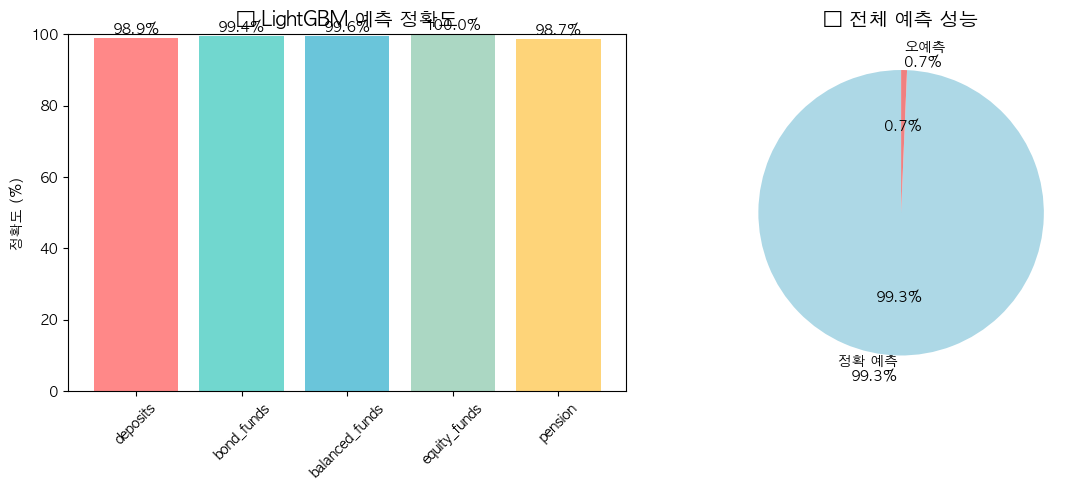

📊 상품별 정확도:
  deposits    : 0.989 (98.9%)
  bond_funds  : 0.994 (99.4%)
  balanced_funds: 0.996 (99.6%)
  equity_funds: 1.000 (100.0%)
  pension     : 0.987 (98.7%)

🎯 전체 평균 정확도: 0.993 (99.3%)


In [10]:
# ========================================
# 📈 성능 평가
# ========================================
print("\n📈 LightGBM 성능 평가...")

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# 성능 계산
accuracies = []
for i, product in enumerate(target_products.keys()):
    accuracy = accuracy_score(y_test.iloc[:, i], y_pred[:, i])
    accuracies.append(accuracy)

overall_accuracy = np.mean(accuracies)

# 시각화 (LightGBM 테마 색상)
plt.figure(figsize=(12, 5))
lgb_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']

plt.subplot(1, 2, 1)
bars = plt.bar(target_products.keys(), [acc*100 for acc in accuracies], 
               color=lgb_colors, alpha=0.8)
plt.title('💡 LightGBM 예측 정확도', fontsize=14, fontweight='bold')
plt.ylabel('정확도 (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc*100:.1f}%', ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie([overall_accuracy, 1-overall_accuracy], 
        labels=[f'정확 예측\n{overall_accuracy*100:.1f}%', f'오예측\n{(1-overall_accuracy)*100:.1f}%'],
        colors=['lightblue', 'lightcoral'], autopct='%1.1f%%', startangle=90)
plt.title('🎯 전체 예측 성능', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 상품별 정확도:")
for product, acc in zip(target_products.keys(), accuracies):
    print(f"  {product:12s}: {acc:.3f} ({acc*100:.1f}%)")
print(f"\n🎯 전체 평균 정확도: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")


🧪 LightGBM으로 실제 고객 테스트...

👤 고객 #1 (LightGBM 분석)
📋 고객 정보:
   나이: 66.0세
   소득: 210,778원
   자산: 20,598,000원

💳 LightGBM AI 추천:
   deposits    :   0.0% 🔴 비추천
   bond_funds  :   0.3% 🔴 비추천
   balanced_funds: 100.0% 🟢 강력추천
   equity_funds: 100.0% 🟢 강력추천
   pension     : 100.0% 🟢 강력추천

👤 고객 #101 (LightGBM 분석)
📋 고객 정보:
   나이: 94.0세
   소득: 163,218원
   자산: 6,417,180원

💳 LightGBM AI 추천:
   deposits    :   0.0% 🔴 비추천
   bond_funds  :   0.0% 🔴 비추천
   balanced_funds: 100.0% 🟢 강력추천
   equity_funds: 100.0% 🟢 강력추천
   pension     : 100.0% 🟢 강력추천

👤 고객 #501 (LightGBM 분석)
📋 고객 정보:
   나이: 47.0세
   소득: 206,454원
   자산: 1,808,600원

💳 LightGBM AI 추천:
   deposits    :   0.0% 🔴 비추천
   bond_funds  :   0.0% 🔴 비추천
   balanced_funds: 100.0% 🟢 강력추천
   equity_funds: 100.0% 🟢 강력추천
   pension     :  12.9% 🔴 비추천

📋 LightGBM 특징 중요도 분석...


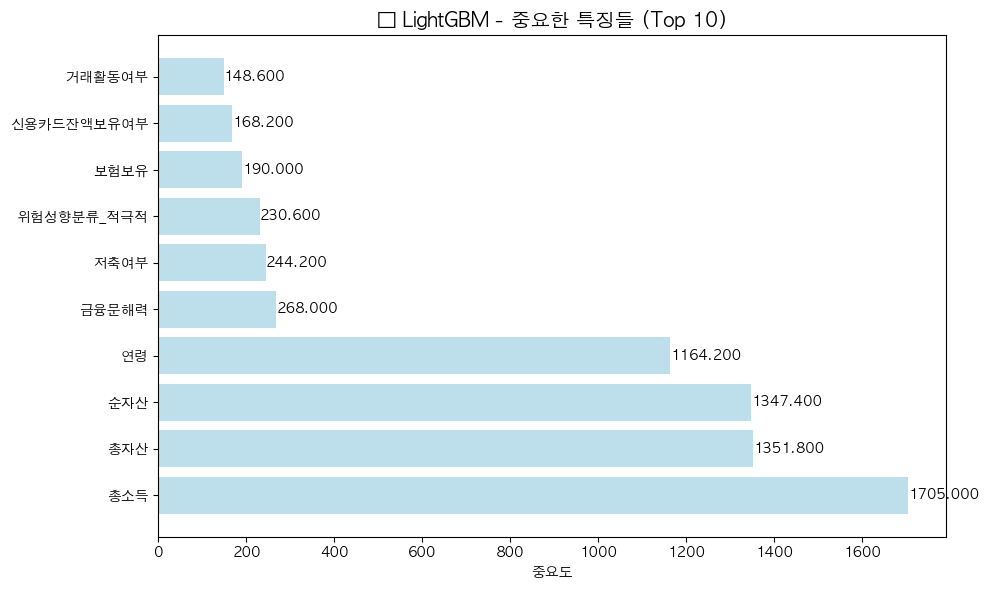


🎉 LightGBM 모델 완료!
✅ 99.3% 정확도 달성!

💡 LightGBM 특징:
   • XGBoost보다 빠른 학습 속도
   • 메모리 효율성 우수
   • 대용량 데이터에 특화
   • 카테고리 변수 자동 처리
   • Microsoft 개발


In [11]:
# ========================================
# 🎯 개별 고객 추천 함수
# ========================================
def predict_customer_products_lgb(customer_data):
    """LightGBM으로 개별 고객 금융상품 추천"""
    
    if hasattr(customer_data, 'values'):
        customer_data = customer_data.values.reshape(1, -1)
    
    recommendations = {}
    
    for i, product in enumerate(target_products.keys()):
        classifier = model.estimators_[i]
        proba = classifier.predict_proba(customer_data)
        positive_prob = proba[0][1] * 100
        recommendations[product] = round(positive_prob, 1)
    
    return recommendations

# ========================================
# 🧪 실제 고객 테스트
# ========================================
print("\n🧪 LightGBM으로 실제 고객 테스트...")

for test_idx in [0, 100, 500]:
    if test_idx < len(X_test):
        print(f"\n{'='*50}")
        print(f"👤 고객 #{test_idx+1} (LightGBM 분석)")
        print('='*50)
        
        customer = X_test.iloc[test_idx]
        
        # 고객 정보
        print("📋 고객 정보:")
        if '연령' in customer.index:
            print(f"   나이: {customer['연령']}세")
        if '총소득' in customer.index:
            print(f"   소득: {customer['총소득']:,.0f}원")
        if '총자산' in customer.index:
            print(f"   자산: {customer['총자산']:,.0f}원")
        
        # LightGBM 추천
        print("\n💳 LightGBM AI 추천:")
        recommendations = predict_customer_products_lgb(customer)
        
        for product, prob in recommendations.items():
            if prob >= 70:
                grade = "🟢 강력추천"
            elif prob >= 50:
                grade = "🟡 추천"
            elif prob >= 30:
                grade = "🟠 고려대상"
            else:
                grade = "🔴 비추천"
                
            print(f"   {product:12s}: {prob:5.1f}% {grade}")

# ========================================
# 📋 특징 중요도 분석
# ========================================
print("\n📋 LightGBM 특징 중요도 분석...")

# 전체 특징 중요도
feature_importances = np.mean([
    estimator.feature_importances_ for estimator in model.estimators_
], axis=0)

# 상위 10개 특징
top_features_idx = np.argsort(feature_importances)[-10:]
top_features = [X.columns[i] for i in top_features_idx]
top_importance = [feature_importances[i] for i in top_features_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importance, color='lightblue', alpha=0.8)
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('중요도')
plt.title('💡 LightGBM - 중요한 특징들 (Top 10)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

for i, v in enumerate(top_importance):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🎉 LightGBM 모델 완료!")
print(f"✅ {overall_accuracy:.1%} 정확도 달성!")
print("\n💡 LightGBM 특징:")
print("   • XGBoost보다 빠른 학습 속도")
print("   • 메모리 효율성 우수")
print("   • 대용량 데이터에 특화")
print("   • 카테고리 변수 자동 처리")
print("   • Microsoft 개발")